Total Parameter Combinations: 364
Total Iterations (Parameter Combinations x CV Folds): 3640
Starting Grid Search...
Fitting 10 folds for each of 364 candidates, totalling 3640 fits
Grid Search Completed.

Best Average AUC: 0.7421 ± 0.0375
Average Accuracy: 0.6895 ± 0.0138
Average Precision: 0.1757 ± 0.0171
Average F1 Score: 0.2766 ± 0.0268

Best Hyperparameters:
  lr__C: 1
  lr__l1_ratio: None
  lr__penalty: l1
  lr__solver: saga
  resampler: RandomOverSampler()
  resampler__sampling_strategy: auto

Generating cross-validated predicted probabilities...
Optimizing threshold to maximize F1 score...

Calculating metrics at the optimal threshold across folds...
  Fold 1: F1=0.3562, Accuracy=0.8481, Precision=0.2921
  Fold 2: F1=0.2963, Accuracy=0.8463, Precision=0.2532
  Fold 3: F1=0.2016, Accuracy=0.8333, Precision=0.1781
  Fold 4: F1=0.3281, Accuracy=0.8608, Precision=0.2917
  Fold 5: F1=0.2969, Accuracy=0.8544, Precision=0.2639


/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


  Fold 6: F1=0.2345, Accuracy=0.8204, Precision=0.1910


/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


  Fold 7: F1=0.3881, Accuracy=0.8673, Precision=0.3333


/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


  Fold 8: F1=0.3259, Accuracy=0.8528, Precision=0.2821
  Fold 9: F1=0.2985, Accuracy=0.8479, Precision=0.2597
  Fold 10: F1=0.3459, Accuracy=0.8592, Precision=0.3026

=== Optimized Threshold ===
Threshold for Maximum F1 Score: 0.70

=== Metrics at Optimal Threshold ===
F1 Score: 0.3072 ± 0.0529
Accuracy: 0.8491 ± 0.0130
Precision: 0.2648 ± 0.0458


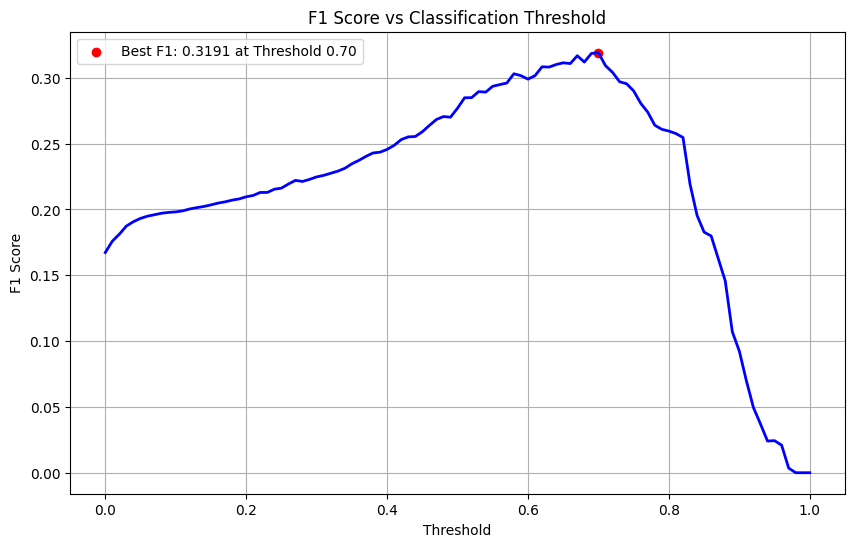

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, f1_score
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
import matplotlib.pyplot as plt
import warnings
from math import prod

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Load the dataset
# Replace the file path with your actual path
data = pd.read_excel("class123_dataset.xlsx")

# Extract the predictors and outcome
X = data.drop('RRI', axis=1)
Y = data['RRI']

# Define the feature indexes to be used as predictors
# Note: Pandas uses 0-based indexing
feature_indexes = [28, 234, 36, 215, 189, 37, 77, 26, 250, 188, 236, 181, 70, 55, 48, 67, 202, 244, 78, 65, 52, 237, 211, 57, 185, 229, 231, 219, 62, 220, 51, 200, 30, 242, 233, 198, 34, 25, 212, 205, 252, 32, 29, 248, 253, 75, 66, 247, 56, 58, 12, 221, 41, 197, 7, 63, 217, 1, 251, 199, 114, 49, 24, 50, 101, 80, 186, 232, 207, 130, 79, 115, 43, 243, 190, 137, 136, 108, 46, 214, 17, 10, 110, 88, 125, 182, 33, 203, 225, 68, 213, 227, 126, 93, 81, 14, 13, 104, 92, 42, 201, 129, 177, 122, 134, 133, 60, 19, 31, 9, 135, 98, 8, 45, 3, 47, 4, 6, 226, 116, 106, 90, 15, 105, 138, 18, 89, 84, 100, 44, 228, 131, 38, 112, 103, 96, 16, 127, 206, 117, 11, 102, 176, 128, 97, 0, 132, 5, 256, 61, 235, 87, 91, 193, 39, 111, 64, 180, 99, 95, 179, 35, 191, 246, 94, 238, 109, 22, 249, 187, 204, 245, 174, 53, 40, 86, 107, 119, 222, 239, 183, 157, 141, 123, 20, 196, 85, 83, 82, 167, 23, 139, 241, 72, 159, 2, 192, 175, 223, 54, 156, 73, 69, 208, 161, 120, 195, 158, 166, 59, 153, 147, 160, 172, 216, 173, 165, 76, 27, 178, 74, 209, 255, 224, 124, 194, 164, 171, 155, 254, 184, 113, 143, 71, 230, 144, 146, 210, 21, 240, 170, 218, 149, 163, 154]

# Select the specified features using .iloc
X_selected = X.iloc[:, feature_indexes]

# Initialize the Logistic Regression Classifier
lr = LogisticRegression(random_state=42, max_iter=10000)

# Initialize the resampling strategies
resamplers = [
    ('smote', SMOTE()),
    ('adasyn', ADASYN()),
    ('random_oversampler', RandomOverSampler())
]

# Create a Pipeline with Resampler and Logistic Regression
pipeline = ImbPipeline([
    ('resampler', SMOTE()),  # Placeholder, will be set in GridSearchCV
    ('lr', lr)
])

# Define the parameter grid for hyperparameter tuning
param_grid = [
    # Logistic Regression with L1 penalty and actual resamplers
    {
        'resampler': [SMOTE(), ADASYN(), RandomOverSampler()],
        'resampler__sampling_strategy': ['auto', 0.2, 0.5, 1.5],
        'lr__penalty': ['l1'],
        'lr__C': [0.1, 1, 10, 100],
        'lr__solver': ['saga'],
        # 'lr__l1_ratio' is not used for 'l1' penalty; set to None
        'lr__l1_ratio': [None]
    },
    # Logistic Regression with L1 penalty and passthrough
    {
        'resampler': ['passthrough'],
        # Exclude 'resampler__sampling_strategy' when passthrough is used
        'lr__penalty': ['l1'],
        'lr__C': [0.1, 1, 10, 100],
        'lr__solver': ['saga'],
        'lr__l1_ratio': [None]
    },
    # Logistic Regression with L2 penalty and actual resamplers
    {
        'resampler': [SMOTE(), ADASYN(), RandomOverSampler()],
        'resampler__sampling_strategy': ['auto', 0.2, 0.5, 1.5],
        'lr__penalty': ['l2'],
        'lr__C': [0.1, 1, 10, 100],
        'lr__solver': ['lbfgs', 'sag', 'saga'],
        'lr__l1_ratio': [None]
    },
    # Logistic Regression with L2 penalty and passthrough
    {
        'resampler': ['passthrough'],
        'lr__penalty': ['l2'],
        'lr__C': [0.1, 1, 10, 100],
        'lr__solver': ['lbfgs', 'sag', 'saga'],
        'lr__l1_ratio': [None]
    },
    # Logistic Regression with ElasticNet penalty and actual resamplers
    {
        'resampler': [SMOTE(), ADASYN(), RandomOverSampler()],
        'resampler__sampling_strategy': ['auto', 0.2, 0.5, 1.5],
        'lr__penalty': ['elasticnet'],
        'lr__C': [0.1, 1, 10, 100],
        'lr__solver': ['saga'],
        'lr__l1_ratio': [0.3, 0.5, 0.7]  # Only relevant for 'elasticnet'
    },
    # Logistic Regression with ElasticNet penalty and passthrough
    {
        'resampler': ['passthrough'],
        'lr__penalty': ['elasticnet'],
        'lr__C': [0.1, 1, 10, 100],
        'lr__solver': ['saga'],
        'lr__l1_ratio': [0.3, 0.5, 0.7]
    }
]


# Define the scoring metrics
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'f1': 'f1'
}

# Define the Stratified 10-Fold Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Calculate the total number of parameter combinations
n_param_combinations = sum([prod([len(v) for v in param_dict.values() if v is not None]) for param_dict in param_grid])

# Calculate the total number of iterations
total_iterations = n_param_combinations * cv.get_n_splits(X_selected, Y)

print(f"Total Parameter Combinations: {n_param_combinations}")
print(f"Total Iterations (Parameter Combinations x CV Folds): {total_iterations}")

# Initialize Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # Use 'roc_auc' to select the best model
    cv=cv,
    n_jobs=7,  # Use all available cores
    verbose=1,  # Set to 1 for basic progress messages
    return_train_score=False
)

# Fit the Grid Search to the data without progress bar
print("Starting Grid Search...")
grid_search.fit(X_selected, Y)
print("Grid Search Completed.")

# Retrieve the best average AUC and its standard deviation
best_auc = grid_search.best_score_
# Retrieve the standard deviation from cv_results_
# Identify the index of the best parameter set
best_index = grid_search.best_index_
best_auc_std = grid_search.cv_results_['std_test_roc_auc'][best_index]

# Retrieve the best hyperparameters
best_params = grid_search.best_params_

# Retrieve the other metrics for the best parameter set
best_accuracy = grid_search.cv_results_['mean_test_accuracy'][best_index]
best_accuracy_std = grid_search.cv_results_['std_test_accuracy'][best_index]

best_precision = grid_search.cv_results_['mean_test_precision'][best_index]
best_precision_std = grid_search.cv_results_['std_test_precision'][best_index]

best_f1 = grid_search.cv_results_['mean_test_f1'][best_index]
best_f1_std = grid_search.cv_results_['std_test_f1'][best_index]

# Output the results
print(f"\nBest Average AUC: {best_auc:.4f} ± {best_auc_std:.4f}")
print(f"Average Accuracy: {best_accuracy:.4f} ± {best_accuracy_std:.4f}")
print(f"Average Precision: {best_precision:.4f} ± {best_precision_std:.4f}")
print(f"Average F1 Score: {best_f1:.4f} ± {best_f1_std:.4f}")
print("\nBest Hyperparameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# Retrieve the best estimator from Grid Search
best_estimator = grid_search.best_estimator_

# Use cross_val_predict to get cross-validated predicted probabilities
# LogisticRegression inherently supports predict_proba
print("\nGenerating cross-validated predicted probabilities...")
y_pred_proba = cross_val_predict(best_estimator, X_selected, Y, cv=cv, method='predict_proba', n_jobs=7)[:, 1]

# Define a range of threshold values to evaluate
thresholds = np.linspace(0.0, 1.0, 101)

# Initialize variables to store the best metrics and threshold
best_threshold = 0.5
best_f1_score = 0.0
best_accuracy = 0.0
best_precision = 0.0

print("Optimizing threshold to maximize F1 score...")

for threshold in thresholds:
    # Convert predicted probabilities to binary predictions based on the threshold
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Calculate F1 score
    current_f1 = f1_score(Y, y_pred)
    
    # Update the best metrics and threshold if current F1 is better
    if current_f1 > best_f1_score:
        best_f1_score = current_f1
        best_threshold = threshold
        best_accuracy = accuracy_score(Y, y_pred)
        best_precision = precision_score(Y, y_pred, zero_division=0)

# Calculate standard deviations using cross-validation
# To compute standard deviations, we'll perform cross-validation predictions and calculate metrics at the best threshold

# Initialize lists to store per-fold metrics
f1_scores = []
accuracies = []
precisions = []

print("\nCalculating metrics at the optimal threshold across folds...")

for fold, (train_idx, test_idx) in enumerate(cv.split(X_selected, Y), 1):
    # Split data
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]
    
    # Fit the model on the training data
    best_estimator.fit(X_train, y_train)
    
    # Predict probabilities on the test data
    y_proba_fold = best_estimator.predict_proba(X_test)[:, 1]
    
    # Apply the optimal threshold
    y_pred_fold = (y_proba_fold >= best_threshold).astype(int)
    
    # Calculate metrics
    fold_f1 = f1_score(y_test, y_pred_fold)
    fold_accuracy = accuracy_score(y_test, y_pred_fold)
    fold_precision = precision_score(y_test, y_pred_fold, zero_division=0)
    
    # Append to lists
    f1_scores.append(fold_f1)
    accuracies.append(fold_accuracy)
    precisions.append(fold_precision)
    
    print(f"  Fold {fold}: F1={fold_f1:.4f}, Accuracy={fold_accuracy:.4f}, Precision={fold_precision:.4f}")

# Calculate mean and standard deviation for the metrics
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)

mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

mean_precision = np.mean(precisions)
std_precision = np.std(precisions)

# Output the optimized threshold and corresponding metrics
print(f"\n=== Optimized Threshold ===")
print(f"Threshold for Maximum F1 Score: {best_threshold:.2f}")

print(f"\n=== Metrics at Optimal Threshold ===")
print(f"F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Precision: {mean_precision:.4f} ± {std_precision:.4f}")

# Plot F1 Score vs Threshold
f1_scores_plot = []
for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(Y, y_pred)
    f1_scores_plot.append(f1)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores_plot, color='blue', lw=2)
plt.scatter(best_threshold, best_f1_score, color='red', 
            label=f'Best F1: {best_f1_score:.4f} at Threshold {best_threshold:.2f}')
plt.title('F1 Score vs Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()